# Mouse Embryonic Cells – SUMO Proteomics Analysis

## Overview

This notebook analyzes SUMO2/3-modified proteins identified in **mouse embryonic cells** using MaxQuant-derived `msms.txt` files.

The goal is to compare datasets processed under the different workflows, SBM3 and standard.

---

## Objectives

- Clean and preprocess MaxQuant protein group outputs  
- Filter for valid SUMO2/3 modification sites  
- Compare datasets (e.g., Standard vs alternative workflow)  
- Visualize dataset intersections  

---

## Input Data

- **MaxQuant output**
  - `msms.txt`
- Dataset-specific SUMO site columns  

---

## Outputs

The notebook generates:

- Peptide identifications per dataset  


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from upsetplot import UpSet
from matplotlib_venn import venn2

import re
from collections import Counter

plt.rcParams["font.family"] = "Arial" 

import biotite.database.entrez as entrez
import biotite.sequence as seq
from biotite.sequence import ProteinSequence
import biotite.sequence.io.fasta as fasta

import mpl_scatter_density 
from matplotlib.colors import LinearSegmentedColormap
from mpl_scatter_density import ScatterDensityArtist
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import scipy.stats as stats
from statannotations.Annotator import Annotator

from scipy.stats import gaussian_kde

%load_ext autoreload
from protein_inference import * 
from extracting_sequences import *

In [2]:
color_map = {
    '0': '#ffbc42',
    'VM': '#ffbc42',
    'SBM 0': '#ffbc42',
    'sbm_o_4': '#2ca02c', 
    'st': '#d81159', 
    'Standard': '#d81159', 
    'Unique Standard': '#d81159',
    'sbm_3': '#73d2de', 
    'SBM 3': '#73d2de', 
    'MQ SBM 3': '#73d2de', 
    'MQ SBM 3 Percolator': '#b7e8ee', 
    'sbm3': '#73d2de',
    'Unique SBM 3': '#73d2de',
    'sbm_8': '#218380',
    'sbm8': '#218380',
    'SBM 8': '#218380', 
    'MSFragger': '#60435f', 
    'MSFragger 9nl Percolator': '#60435f', 
    'Unique MSFragger': '#60435f'
}

custom_order = ['Standard', 'SBM 3']

# Importing the data

In [3]:
root_dir = '../mouse_embro_fibroblasts' 
f_path = "../MOUSE.fasta"

In [4]:
# this part of te code reads the dataset and merges them. 
# A new column is created where the dataset folder defines the dataset name , e.g sbm3 or standard
dfs = []

for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file == 'msms.txt':
            file_path = os.path.join(subdir, file)
            parent_folder = os.path.basename(os.path.dirname(subdir))
            df = pd.read_csv(file_path, delimiter="\t")
            
            new_columns = {}
            for col in df.columns:
                if 'SUMO2' in col:
                    new_col_name = 'SUMO2' + col.split('SUMO2', 1)[1]
                    new_columns[col] = new_col_name
            
            df.rename(columns=new_columns, inplace=True)
            df['Dataset'] = parent_folder
            dfs.append(df)

big_df = pd.concat(dfs, ignore_index=True)

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_23361/1711247926.py:9: DtypeWarning: Columns (59,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_23361/1711247926.py:9: DtypeWarning: Columns (59,72,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")


In [5]:
#loading the sites.txt similarly 

dfs = []

for subdir, _, files in os.walk(root_dir):
    for file in files:
        if 'SUMO2_3-DVFQQQTGGSites.txt' in file:
            file_path = os.path.join(subdir, file)
            parent_folder = os.path.basename(os.path.dirname(subdir))
            df = pd.read_csv(file_path, delimiter="\t")
            
            new_columns = {}
            for col in df.columns:
                if 'SUMO2' in col:
                    new_col_name = 'SUMO2' + col.split('SUMO2', 1)[1]
                    new_columns[col] = new_col_name
            
            df.rename(columns=new_columns, inplace=True)
            df['Dataset'] = parent_folder

            dfs.append(df)

sites_df = pd.concat(dfs, ignore_index=True)

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_23361/1017989954.py:9: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")


In [6]:
sites_df['MS/MS ID'] = sites_df['MS/MS IDs'].str.split(';')
sites_df_long = sites_df.explode('MS/MS ID').reset_index(drop=True)
sites_df_long = sites_df_long.dropna(subset=['MS/MS ID'])
sites_df_long['MS/MS ID'] = sites_df_long['MS/MS ID'].astype(int)

print(len(big_df))
big_df = big_df.merge(sites_df_long_cleaned, left_on=['id', 'Dataset'], right_on=['MS/MS ID', 'Dataset'], how='left', suffixes=('', '_sites_table'))
print(len(big_df))

2116153
2116153


In [7]:
dfs = []

for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file == 'evidence.txt':
            file_path = os.path.join(subdir, file)
            parent_folder = os.path.basename(os.path.dirname(subdir))
            df = pd.read_csv(file_path, delimiter="\t")
            
            new_columns = {}
            for col in df.columns:
                if 'SUMO2' in col:
                    new_col_name = 'SUMO2' + col.split('SUMO2', 1)[1]
                    new_columns[col] = new_col_name
            
            df.rename(columns=new_columns, inplace=True)
            df['Dataset'] = parent_folder
            #df['PSMId'] = df.apply(lambda x: f"{'decoy' if pd.notna(x['Reverse']) else 'target'}_0_{x['Scan number']}_{x['Raw file']}_{x['Charge']}_1", axis=1)

            dfs.append(df)

evi_df = pd.concat(dfs, ignore_index=True)

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_23361/125041966.py:8: DtypeWarning: Columns (64) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_23361/125041966.py:8: DtypeWarning: Columns (64) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")


In [9]:
print(len(evi_df))
merged_df = evi_df.merge(big_df, left_on=['id', 'Dataset'], right_on=['Evidence ID', 'Dataset'], how='left', suffixes=('', '_msms_table'))

print(len(merged_df))

2059714
2116153


In [10]:
print(len(big_df))
print(len(sites_df))
print(len(sites_df_long))
print(len(evi_df))


2116153
195324
471879
2059714


# Preprocessing

* Remove reverse
* filter contaminants
* convert data formats 

In [11]:
big_df = big_df[big_df['Contaminant'] != '+']
big_df['Reverse'].fillna('-', inplace=True)
big_df['Modified sequence'] = big_df['Modified sequence'].str.replace(r'st_o_SUMO2/3-DVFQQQTGG|ST_2_SUMO2/3-DVFQQQTGG|SBM_4_o_SUMO2/3-DVFQQQTGG|SBM_5_o_SUMO2/3-DVFQQQTGG|SBM_3_o_SUMO2/3-DVFQQQTGG|SBM_2_o_SUMO2/3-DVFQQQTGG|SBM_8_o_SUMO2/3-DVFQQQTGG|SBM_0_o_SUMO2/3-DVFQQQTGG', 'su', regex=True).str.replace(r'\(Acetyl \(Protein N-term\)\)', '', regex=True).str.replace(r'\(Oxidation \(M\)\)', '', regex=True)  
big_df['Masses'] = big_df['Masses'].astype(str)
big_df['Intensities'] = big_df['Intensities'].astype(str)
big_df['Matches'] = big_df['Matches'].astype(str)
big_df['Masses'] = big_df['Masses'].apply(lambda x: [float(val) for val in x.split(';')])
big_df['Intensities'] = big_df['Intensities'].apply(lambda x: [float(val) for val in x.split(';')])
big_df['Matches'] = big_df['Matches'].apply(lambda x: [val for val in x.split(';')])
big_df['Proteins'] = big_df['Proteins'].str.split(';')
big_df['Positions within proteins'] = big_df['Positions within proteins'].str.split(';')
big_df['Positions within proteins'] = big_df['Positions within proteins'].apply(
    lambda x: [int(pos) for pos in x if isinstance(x, list) and pos.strip().isdigit()] if isinstance(x, list) else []
)

In [13]:
selected = big_df[big_df['Dataset'].isin(['SBM 3', 'Standard'])]
selected[["Modified sequence", "Dataset"]].drop_duplicates().to_csv("mod_peps_mef.txt", index=False, header=False, sep="\t")


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_23361/376858344.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=sites_counts, x='Dataset', y='Count', palette=palette)


SBM 3 vs Standard (+17.7%)


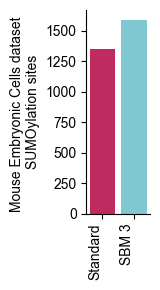

In [14]:
sites_df_org = sites_df[sites_df['Dataset'].isin(['SBM 3', 'Standard'])]
sites_df_org = sites_df_org[~sites_df_org['Leading proteins'].str.startswith(('CON', 'REV'))]

sites_counts = sites_df_org.groupby(['Dataset']).size().reset_index(name='Count')

count_standard = sites_counts.loc[sites_counts['Dataset'] == 'Standard', 'Count'].values[0]
count_sbm3 = sites_counts.loc[sites_counts['Dataset'] == 'SBM 3', 'Count'].values[0]
percentage_increase = ((count_sbm3 - count_standard) / count_standard) * 100

sites_counts['Dataset'] = pd.Categorical(sites_counts['Dataset'], categories=custom_order, ordered=True)
sites_counts = sites_counts.sort_values('Dataset')

plt.figure(figsize=(1.7, 3))
palette = [color_map[ds] for ds in sites_counts['Dataset']]
ax = sns.barplot(data=sites_counts, x='Dataset', y='Count', palette=palette)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#for container in ax.containers:
#    ax.bar_label(container, fmt='%d', label_type='edge', padding=2)

plt.xticks(rotation=90, ha='right')
plt.ylabel('Mouse Embryonic Cells dataset \nSUMOylation sites')
plt.xlabel('')
print(f"SBM 3 vs Standard (+{percentage_increase:.1f}%)")
plt.tight_layout()

output_path = fig_dir + "sites.pdf"
plt.savefig(output_path, transparent=True)
plt.show()


In [17]:
big_df = big_df[big_df['Dataset'].isin(['SBM 3', 'Standard'])]

big_df["Modified sequence"] = big_df["Modified sequence"].str.replace(r'\(su\)', '[su]', regex=True).str.replace(r'_', '', regex=True).str.replace(r'\(Acetyl \(Protein N-term\)\)', '', regex=True).str.replace(r'\(Oxidation \(M\)\)', '', regex=True)     # (Oxidation (M))

big_df = big_df[big_df['Reverse'] != '+']

all_counts = big_df.groupby('Dataset').size()

df_sumo = big_df[big_df['SUMO2/3-DVFQQQTGG'] == 1]
df_no_sumo = big_df[big_df['SUMO2/3-DVFQQQTGG'] == 0]

df_sumo_unique = df_sumo.groupby('Dataset').apply(
    lambda x: x.drop_duplicates(subset=['Modified sequence'], keep='first')
).reset_index(drop=True)

sumo_counts = df_sumo.groupby('Dataset').size()
unique_sumo_counts = df_sumo_unique.groupby('Dataset').size()

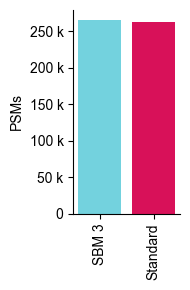

In [18]:
fig, ax_psms = plt.subplots(figsize=(2,3))

psm_bars = ax_psms.bar(
    all_counts.index,
    all_counts.values,
    color=[color_map.get(dataset, 'grey') for dataset in all_counts.index]
)

ax_psms.set_xlabel('')
ax_psms.set_ylabel('PSMs')
ax_psms.set_title('')
ax_psms.set_xticks(range(len(all_counts.index)))
ax_psms.set_xticklabels(all_counts.index, rotation=90)
ax_psms.spines['right'].set_visible(False)
ax_psms.spines['top'].set_visible(False)
ax_psms.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
output_path = fig_dir + "nr_psms_adipocytes.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

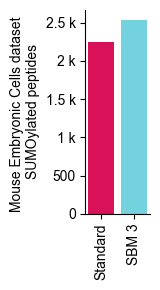

In [19]:
fig, ax = plt.subplots(figsize=(1.7, 3))
unique_sumo_counts = unique_sumo_counts.reindex(custom_order)
bars = ax.bar(unique_sumo_counts.index, unique_sumo_counts.values, 
    color=[color_map.get(dataset, 'grey') for dataset in unique_sumo_counts.index]
)

#for bar in bars:
#    height = bar.get_height()
#    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('')
ax.set_ylabel('Mouse Embryonic Cells dataset \nSUMOylated peptides')
ax.set_title('')
ax.set_xticks(unique_sumo_counts.index) 
ax.set_xticklabels(unique_sumo_counts.index, rotation=90) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
file_path = fig_dir + "nr_sumoylated_peptides_mef.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

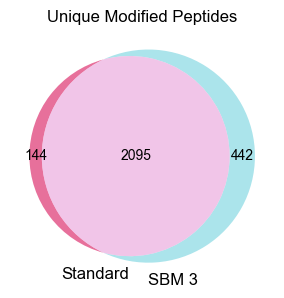

In [20]:
datasets = df_sumo_unique['Dataset'].unique()

datasets = sorted(datasets, key=lambda d: list(color_map.keys()).index(d))  # optional: enforce order from color_map
sequence_sets = {
    ds: set(df_sumo_unique[df_sumo_unique['Dataset'] == ds]['Modified sequence'])
    for ds in datasets
}

set_colors = [color_map[ds] for ds in datasets]

# Plot
plt.figure(figsize=(3, 3))

if len(sequence_sets) == 2:
    venn2(subsets=sequence_sets.values(), set_labels=sequence_sets.keys(), set_colors=set_colors, alpha=0.6)
elif len(sequence_sets) == 3:
    venn3(subsets=sequence_sets.values(), set_labels=sequence_sets.keys(), set_colors=set_colors, alpha=0.6)
else:
    print("Venn diagram supports only 2 or 3 datasets.")

plt.title("Unique Modified Peptides")
plt.tight_layout()
file_path = fig_dir + "venn_mef.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

In [22]:
df_sumo_unique_w_uniprot = process_data_msms_MQ(df_sumo_unique, species = 'mouse') # custom function see protein_inference.py

/Users/hmt128/miniconda3/lib/python3.11/site-packages/biotite/sequence/io/fasta/convert.py:248: UserWarning: ProteinSequence objects do not support selenocysteine (U), occurrences were substituted by cysteine (C)
  warnings.warn(


In [28]:
dataset_names = df_sumo_unique_w_uniprot['Dataset'].unique()

dataset_sequence_sets = {
    name: set(df_sumo_unique_w_uniprot[df_sumo_unique_w_uniprot['Dataset'] == name]['Gene_name'])
    for name in dataset_names
}

unique_gene_names_per_dataset = {
    name: gene_set - set.union(*(s for n, s in dataset_sequence_sets.items() if n != name))
    for name, gene_set in dataset_sequence_sets.items()
}

In [29]:
# These are the genes used at input for STRING network. Shown in the supplementary material

for gene in unique_gene_names_per_dataset['SBM 3']:
    print(gene)

Chtop
Slc4a7
Mme
Rtf1
Tlr7
Mef2c
Supt6h
Gar1
Mybbp1a
Zfp105
Postn
Ncor2
Mcm2
Cenpp
Rpl12
Irf2bpl
Gm12888
Sfxn1
Arhgef2
Hnrnpl
H3c2; H3c3; H3c4; H3c6; H3c7; H3c13; H3c14; H3c15
Gbf1
Poldip3
Clgn
Znf516
Kansl2
Bnc1
Rpl26
Flnb
Tomm5
Tasor2
Calu
Usp7
Rsbn1
Tspyl2
Kmt2a
Cavin3
Ccdc150
Pno1
Mta2
Fyttd1
Slf2
Golga5
Hnrnpa2b1
Gtf3c1
Bod1l
Inppl1
Psmc1
Sap18
Sap130
Khdrbs3
Rell1
Utp3
Wrn
Osbpl8
Polr3f
Morc2a
Ak9
U2surp
Pole
Exosc9
Rita1
Eme1
Ifi30
Csrp1
Lpcat2
Aldoa
Tet3
Thsd7a
Fkbp4
Dpf1
Znf821
Ganc
Pakap
Pou5f1
Ints12
H2bc14
Pikfyve
Vapb
Eif4g3
Smarcb1
Srrm1
Thop1
Map3k7
Tfdp2
Noc3l
Cdk11b
Dhx8
Ep300
Slf1
Lamtor3
Smad4
Nol11
Cep290
Tmsb4x
Suds3
Akirin2
Srsf1
Setdb1
Zfp282
Lmnb1
Kdm6b


In [30]:
for gene in unique_gene_names_per_dataset['Standard']:
    print(gene)

Parp4
Nfkb1
Mgat5
Tp53
Ckap2
Kdm2b
Gm8267
Cox10
Kdm4a
Niban2
Sf3b3
Myo18a
Pycr2
Znf287
Xirp2
Lrrc47
Col4a1
Tmem201
Frmpd4
Usp17lb
Sipa1l1
Naa25
Tcf25
Kif4
Cav1
Rpl23
Rack1
Nsmce1
Fkbp14
Trim54
Ipo4
Lig1
Birc7
Mef2a
Golgb1
Zbtb14
Klra4
Polr2b
Bicdl1
Gtpbp4
Dhrs7l
Myh11
Mettl1
Slc9a4
Aqr
Col7a1
Kif5b
Cep250
Rbm19
Vps72
Pias4
Ptpro
Igkv6-17
Dph7
Ect2
